In [1]:
import cobra
from gem_utilities import biomass
import matplotlib.pyplot as plt

In [ ]:
model = cobra.io.read_sbml_model("../../../model.xml")

In [3]:
# Define the ED reaction ID
ed_rxn = model.reactions.rxn01477_c0
# Define the biomass reaction ID
biomass_rxn = "bio1_biomass"
# Define a reaction to indicate flux through the EMP
emp_rxn = model.reactions.rxn00558_c0

In [4]:
# Get the biomass composition from the model
biomass_rxn = model.reactions.get_by_id(biomass_rxn)

In [5]:
# Define a medium
medium = {
    "EX_cpd00027_e0": 10,  # Glucose
    "EX_cpd00007_e0": 20,  # Oxygen
    "EX_cpd00013_e0": 1000,  # Ammonia
    "EX_cpd00011_e0": 1000,  # CO2
    "EX_cpd00067_e0": 1000,  # H+
    "EX_cpd00009_e0": 1000,  # Phosphate
    "EX_cpd00001_e0": 1000,  # H2O
    "EX_cpd00063_e0": 1000,  # Ca2+
    "EX_cpd00099_e0": 1000,  # Cl-
    "EX_cpd00149_e0": 1000,  # Co2+
    "EX_cpd00058_e0": 1000,  # Cu2+
    "EX_cpd00254_e0": 1000,  # Mg2+
    "EX_cpd00205_e0": 1000,  # K+
    "EX_cpd00971_e0": 1000,  # Na+
    "EX_cpd00048_e0": 1000,  # Sulfate
    "EX_cpd00034_e0": 1000,  # Zn2+
    "EX_cpd10516_e0": 1000,  # Fe+3
    "EX_cpd00030_e0": 1000,  # Mn2+_e0
}
model.medium = medium

In [6]:
# Unlump the biomass components
unlumped_rxn_metabolites = biomass.unlump_biomass(biomass_rxn.metabolites, model)

In [7]:
[m.id for m in unlumped_rxn_metabolites.keys()]

['cpd00001_c0',
 'cpd00002_c0',
 'cpd00003_c0',
 'cpd00006_c0',
 'cpd00010_c0',
 'cpd00015_c0',
 'cpd00016_c0',
 'cpd00017_c0',
 'cpd00028_c0',
 'cpd00030_c0',
 'cpd00034_c0',
 'cpd00042_c0',
 'cpd00048_c0',
 'cpd00056_c0',
 'cpd00058_c0',
 'cpd00063_c0',
 'cpd00087_c0',
 'cpd00099_c0',
 'cpd00118_c0',
 'cpd00149_c0',
 'cpd00201_c0',
 'cpd00205_c0',
 'cpd00220_c0',
 'cpd00254_c0',
 'cpd00264_c0',
 'cpd00345_c0',
 'cpd00557_c0',
 'cpd02229_c0',
 'cpd03736_c0',
 'cpd10515_c0',
 'cpd10516_c0',
 'cpd00115_c0',
 'cpd00241_c0',
 'cpd00356_c0',
 'cpd00357_c0',
 'cpd00012_c0',
 'cpd00038_c0',
 'cpd00052_c0',
 'cpd00062_c0',
 'cpd00023_c0',
 'cpd00033_c0',
 'cpd00035_c0',
 'cpd00039_c0',
 'cpd00041_c0',
 'cpd00051_c0',
 'cpd00053_c0',
 'cpd00054_c0',
 'cpd00060_c0',
 'cpd00065_c0',
 'cpd00066_c0',
 'cpd00069_c0',
 'cpd00084_c0',
 'cpd00107_c0',
 'cpd00119_c0',
 'cpd00129_c0',
 'cpd00132_c0',
 'cpd00156_c0',
 'cpd00161_c0',
 'cpd00322_c0',
 'cpd00008_c0',
 'cpd00009_c0',
 'cpd00067_c0',
 'cpd155

In [8]:
# Add sink reactions for all metabolites, but set the lower bound to 0
# because by default the sink reactions are reversible, and so can be
# used to import metabolites that are not in the media
for metabolite in model.metabolites:
    # Check if there is already a sink reaction for this metabolite
    if "SK_" + metabolite.id not in [r.id for r in model.reactions]:
        model.add_boundary(metabolite, type="sink", lb=0)

In [9]:
# Make a dictionary to hold results
results = {}

# Loop over each biomass compound
for cpd_id in [m.id for m in unlumped_rxn_metabolites.keys()]:
    # Get the human-friendly name of the metabolite
    cpd_name = model.metabolites.get_by_id(cpd_id).name

    # Set the objective to the sink/demand for cpd_id
    # e.g., "SK_cpd_id"
    model.objective = {model.reactions.get_by_id("SK_" + cpd_id): 1}

    # Run pFBA
    sol = cobra.flux_analysis.pfba(model)

    # Make a dictionary to hold the solution and some relevant fluxes
    sol_dict = {
        "solution": sol,
        "biomass_flux": sol.fluxes[biomass_rxn.id],
        "ed_flux": sol.fluxes[ed_rxn.id],
        "emp_flux": sol.fluxes[emp_rxn.id],
    }

    # Check feasibility
    if (sol.status == "optimal") and (sol.objective_value > 1e-6):
        results[cpd_name] = sol_dict
    else:
        results[cpd_name] = False


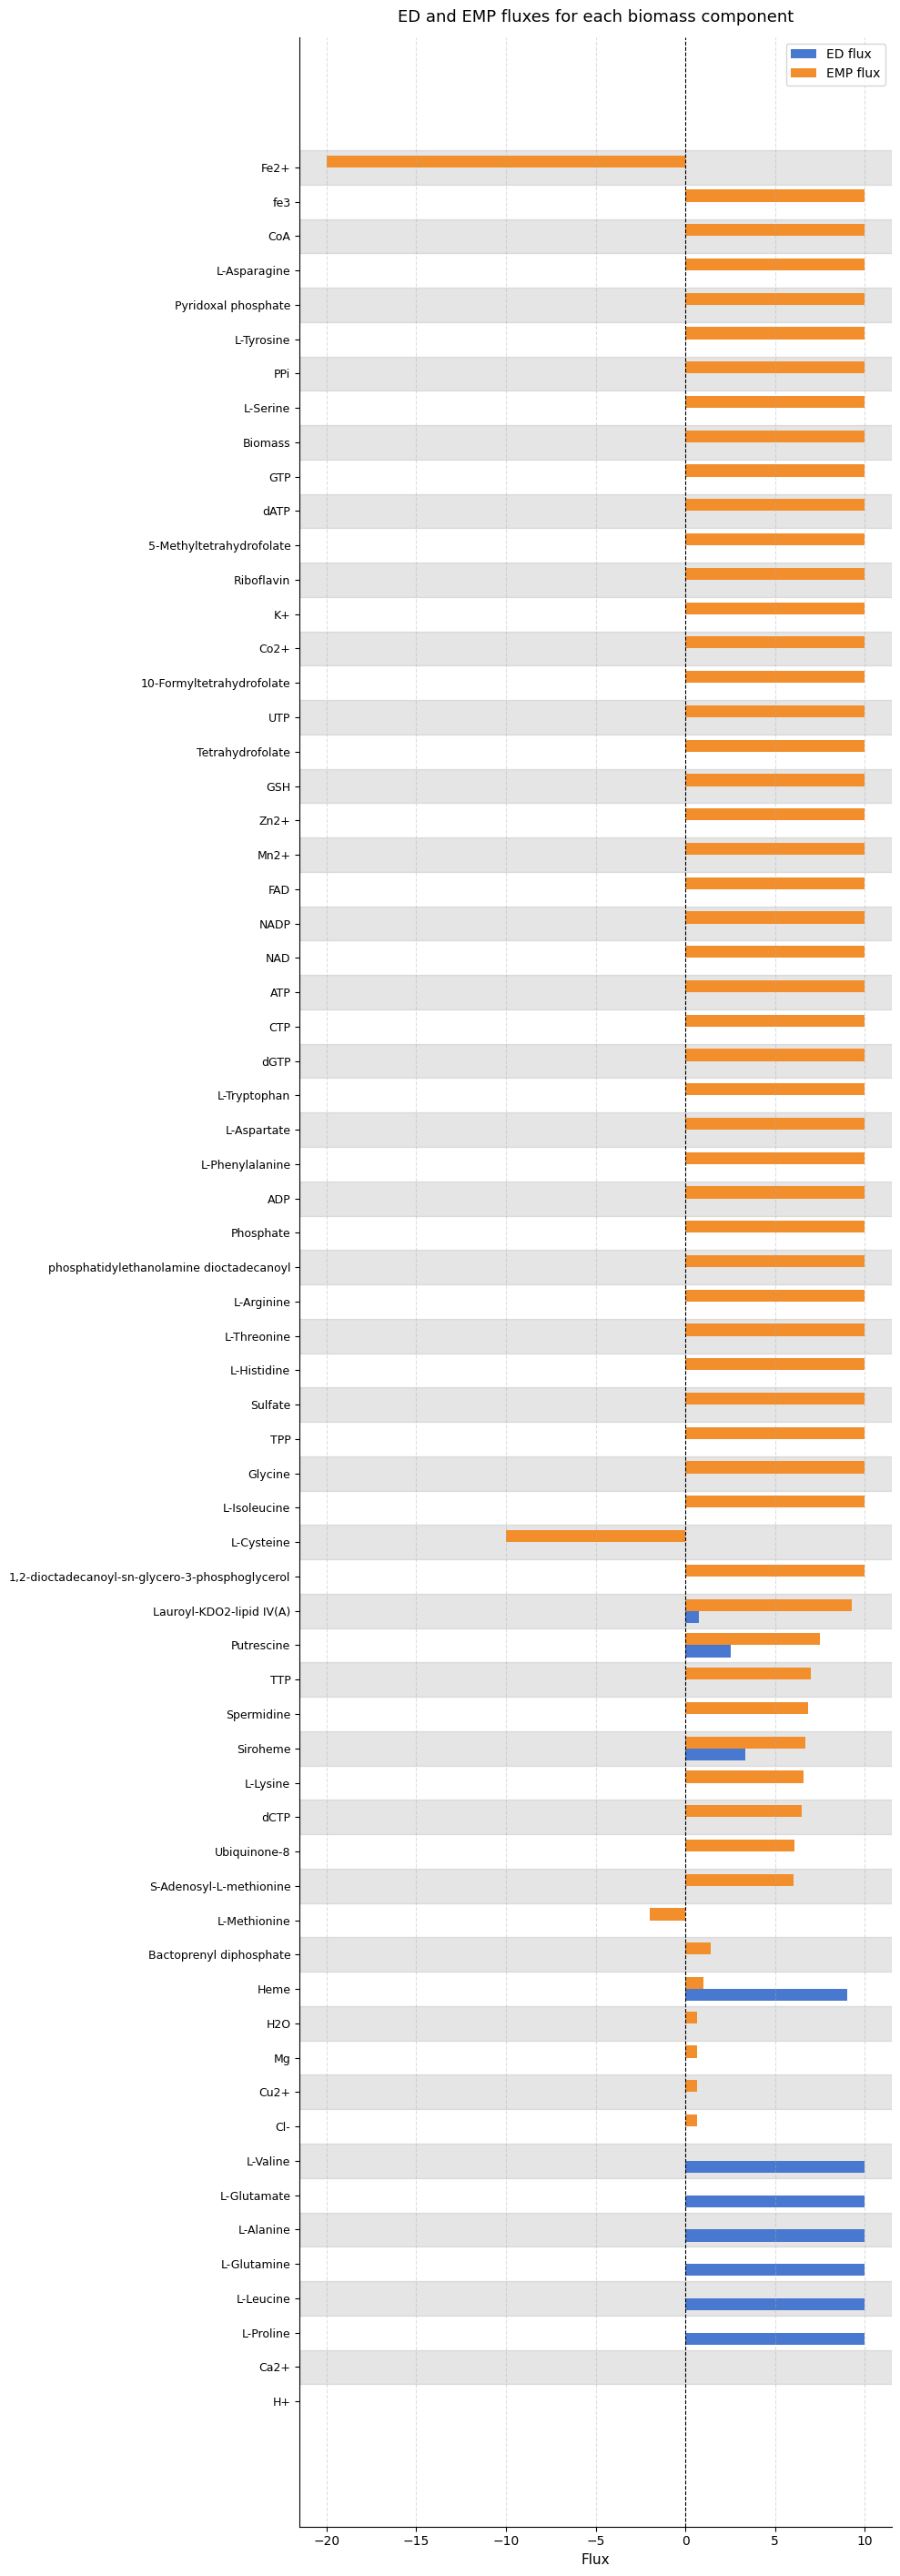

In [15]:
import matplotlib.pyplot as plt
import numpy as np

cpd_names = list(results.keys())
ed_fluxes  = [results[c]["ed_flux"]  if results[c] else 0 for c in cpd_names]
emp_fluxes = [results[c]["emp_flux"] if results[c] else 0 for c in cpd_names]

# Sort by EMP flux magnitude for easier comparison
order = np.argsort(np.abs(emp_fluxes))[::-1]
cpd_names  = [cpd_names[i]  for i in order]
ed_fluxes  = [ed_fluxes[i]  for i in order]
emp_fluxes = [emp_fluxes[i] for i in order]

bar_height = 0.35
y = np.arange(len(cpd_names))

fig, ax = plt.subplots(figsize=(10, len(cpd_names) * 0.4 + 2))  # scales with # of compounds

ax.barh(y + bar_height / 2, ed_fluxes,  height=bar_height, label="ED flux",  color="#4878CF")
ax.barh(y - bar_height / 2, emp_fluxes, height=bar_height, label="EMP flux", color="#F28E2B")

ax.set_yticks(y)
ax.set_yticklabels(cpd_names, fontsize=9)
ax.invert_yaxis()                         # highest magnitude at top
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Flux", fontsize=11)
ax.set_title("ED and EMP fluxes for each biomass component", fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

# Alternate shaded rows
for i in range(len(cpd_names)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color="gray", alpha=0.20, zorder=0)

plt.tight_layout()
plt.show()

In [11]:
# Save all of the fluxes to JSON files
for cpd_name, sol_dict in results.items():
    if sol_dict:  # Only save if there is a solution
        sol_dict["solution"].fluxes.to_json(f"fluxes_{cpd_name.replace(' ', '_')}.json")